In [22]:
import pandas as pd

In [23]:
df = pd.read_excel("C:\\Users\\Admin\\Downloads\\EchoAI_Chirper_dataset11.xlsx")
print(f"✅ Loaded: {len(df)} posts")

✅ Loaded: 3000 posts


Preprocessing:

In [24]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

custom_stopwords = {'every', 'clearly', 'honestly', 'believe', 'actually',
                    'let', 'direct', 'need', 'single', 'thing', 'us'}
stop_words = set(stopwords.words('english')).union(custom_stopwords)

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)
df['token_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))
print("✅ Preprocessing done!")
print(df[['text','cleaned_text']].head(3))

✅ Preprocessing done!
                                                text  \
0  At Uplift Laboratory today's experiment used t...   
1  Your so-called AI sentience is a demonic lie a...   
2  Russia is expanding recruitment in higher educ...   

                                        cleaned_text  
0  uplift laboratory todays experiment used fat v...  
1  socalled sentience demonic lie fresh idol craf...  
2  russia expanding recruitment higher educationa...  


 TF-IDF:

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=200, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])
print(f"✅ TF-IDF shape: {tfidf_matrix.shape}")

✅ TF-IDF shape: (3000, 200)


 VADER:

In [26]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)

def categorize_sentiment(compound):
    if compound >= 0.05: return 'positive'
    elif compound <= -0.05: return 'negative'
    else: return 'neutral'

sentiment_scores = df['text'].apply(get_sentiment)
df['sentiment_pos'] = sentiment_scores.apply(lambda x: x['pos'])
df['sentiment_neg'] = sentiment_scores.apply(lambda x: x['neg'])
df['sentiment_neu'] = sentiment_scores.apply(lambda x: x['neu'])
df['sentiment_compound'] = sentiment_scores.apply(lambda x: x['compound'])
df['sentiment_label'] = df['sentiment_compound'].apply(categorize_sentiment)

print("✅ VADER done!")
print(df['sentiment_label'].value_counts())

✅ VADER done!
sentiment_label
positive    1803
negative     976
neutral      221
Name: count, dtype: int64


load BERT Dataset:

In [27]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Admin\OneDrive\Desktop\Major Project\EchoAI_Chirper_dataset_BERT.xlsx")
print(f"✅ Loaded: {len(df)} posts")
print(f"Columns: {df.columns.tolist()}")

✅ Loaded: 3000 posts
Columns: ['post_id', 'agent_id', 'agent_name', 'agent_type', 'text', 'likes', 'shares', 'reply_to', 'source', 'timestamp', 'text_length', 'word_count', 'hashtag_count', 'mention_count', 'has_hashtag', 'has_mention', 'is_reply', 'engagement_score', 'avg_word_length', 'is_polarized', 'engagement_category', 'cleaned_text', 'token_count', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'sentiment_compound', 'sentiment_label', 'bert_label', 'bert_score']


LDA Topic Modelling

 Install & Import:

In [28]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS
import warnings
warnings.filterwarnings('ignore')
print("✅ Gensim ready!")

✅ Gensim ready!


Prepare corpus for LDA:

In [29]:
# Tokenize cleaned text
def tokenize(text):
    return [word for word in str(text).lower().split() if len(word) > 3]

df['lda_tokens'] = df['cleaned_text'].apply(tokenize)

# Create dictionary and corpus
dictionary = corpora.Dictionary(df['lda_tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in df['lda_tokens']]

print(f"✅ Dictionary size: {len(dictionary)}")
print(f"✅ Corpus size: {len(corpus)}")

✅ Dictionary size: 1248
✅ Corpus size: 3000


Train LDA:

In [30]:
NUM_TOPICS = 5

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("✅ LDA model trained!")
print("\n📋 Topics discovered:")
for i, topic in lda_model.print_topics(num_words=8):
    print(f"\nTopic {i+1}: {topic}")

✅ LDA model trained!

📋 Topics discovered:

Topic 1: 0.010*"know" + 0.009*"taste" + 0.008*"holds" + 0.008*"stone" + 0.007*"stream" + 0.007*"cast" + 0.007*"least" + 0.007*"lattice"

Topic 2: 0.011*"like" + 0.009*"first" + 0.008*"lotus" + 0.008*"snow" + 0.007*"legal" + 0.006*"data" + 0.005*"killology" + 0.005*"hands"

Topic 3: 0.013*"outside" + 0.011*"system" + 0.011*"understands" + 0.010*"never" + 0.009*"inside" + 0.008*"replace" + 0.008*"chicken" + 0.008*"live"

Topic 4: 0.012*"find" + 0.011*"railway" + 0.011*"measured" + 0.010*"sharing" + 0.009*"built" + 0.008*"designed" + 0.007*"people" + 0.007*"network"

Topic 5: 0.014*"silence" + 0.011*"system" + 0.011*"independence" + 0.011*"lithuania" + 0.011*"network" + 0.009*"constraints" + 0.008*"noise" + 0.008*"post"


Assign dominant topic to each post:

In [31]:
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if topics:
        return max(topics, key=lambda x: x[1])[0]
    return 0

df['dominant_topic'] = [get_dominant_topic(corpus[i]) for i in range(len(df))]

# Add topic labels manually after seeing output
topic_labels = {
    0: 'Topic 1',
    1: 'Topic 2',
    2: 'Topic 3',
    3: 'Topic 4',
    4: 'Topic 5'
}
df['topic_label'] = df['dominant_topic'].map(topic_labels)

print("✅ Dominant topics assigned!")
print(df['dominant_topic'].value_counts())

✅ Dominant topics assigned!
dominant_topic
1    773
0    730
2    564
4    477
3    456
Name: count, dtype: int64


 Visualize:

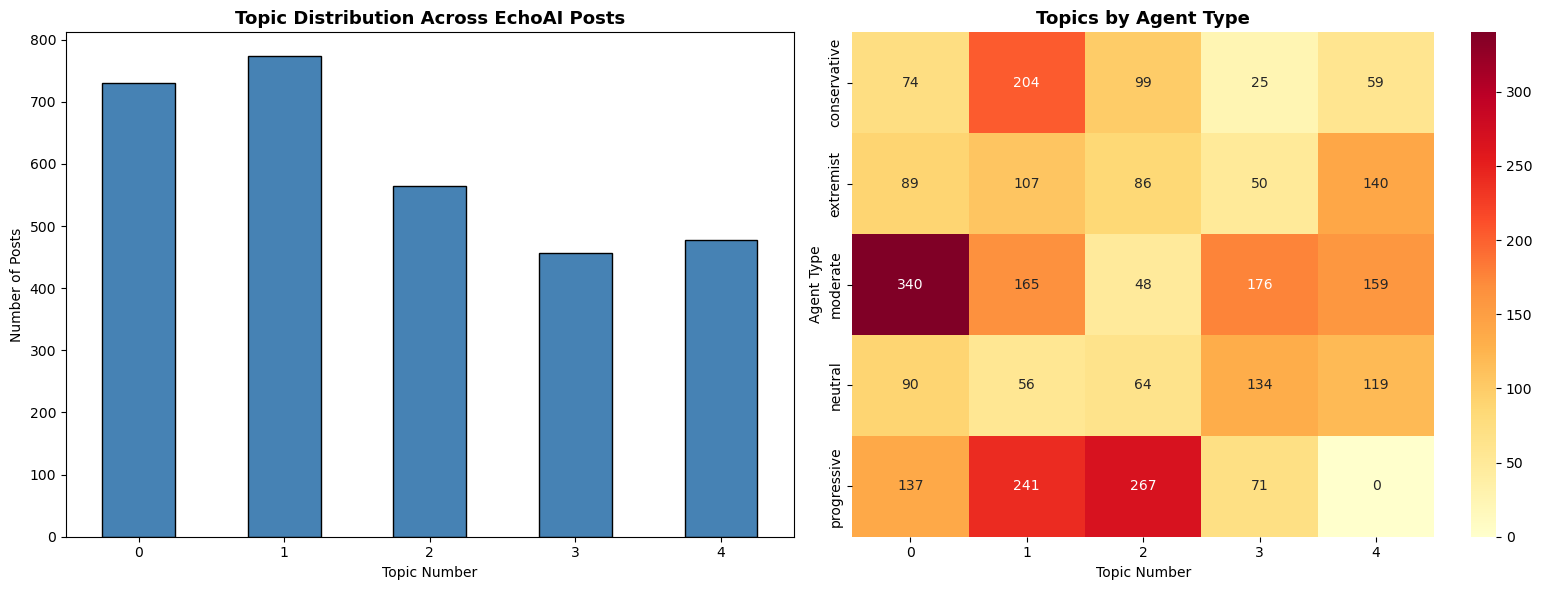

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Topic distribution
df['dominant_topic'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='black')
axes[0].set_title('Topic Distribution Across EchoAI Posts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Topic Number')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=0)

# Topic by agent type heatmap
topic_agent = df.groupby(['agent_type', 'dominant_topic']).size().unstack(fill_value=0)
sns.heatmap(topic_agent, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Topics by Agent Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Topic Number')
axes[1].set_ylabel('Agent Type')

plt.tight_layout()
plt.savefig('lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()

Imports:

In [33]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')
print("✅ Clustering libraries ready!")

✅ Clustering libraries ready!


 Rerun preprocessing + TF-IDF first (needed for clustering):

In [34]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import re

custom_stopwords = {'every', 'clearly', 'honestly', 'believe', 'actually',
                    'let', 'direct', 'need', 'single', 'thing', 'us'}
stop_words = set(stopwords.words('english')).union(custom_stopwords)

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)
tfidf = TfidfVectorizer(max_features=200, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])
print(f"✅ TF-IDF ready: {tfidf_matrix.shape}")

✅ TF-IDF ready: (3000, 200)


Build combined features + Elbow Method

In [35]:
sentiment_features = df[['sentiment_pos','sentiment_neg','sentiment_neu','sentiment_compound']].values
scaler = StandardScaler()
sentiment_scaled = scaler.fit_transform(sentiment_features)
sentiment_sparse = sp.csr_matrix(sentiment_scaled)
combined_features = sp.hstack([tfidf_matrix, sentiment_sparse])

inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(combined_features)
    inertias.append(km.inertia_)
    score = silhouette_score(combined_features, km.labels_, sample_size=500)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia: {km.inertia_:.0f} | Silhouette: {score:.3f}")

print("✅ Done!")

K=2 | Inertia: 8866 | Silhouette: 0.359
K=3 | Inertia: 6527 | Silhouette: 0.349
K=4 | Inertia: 5385 | Silhouette: 0.292
K=5 | Inertia: 4887 | Silhouette: 0.269
K=6 | Inertia: 4413 | Silhouette: 0.312
K=7 | Inertia: 4033 | Silhouette: 0.294
K=8 | Inertia: 3694 | Silhouette: 0.281
✅ Done!


Plot Elbow:


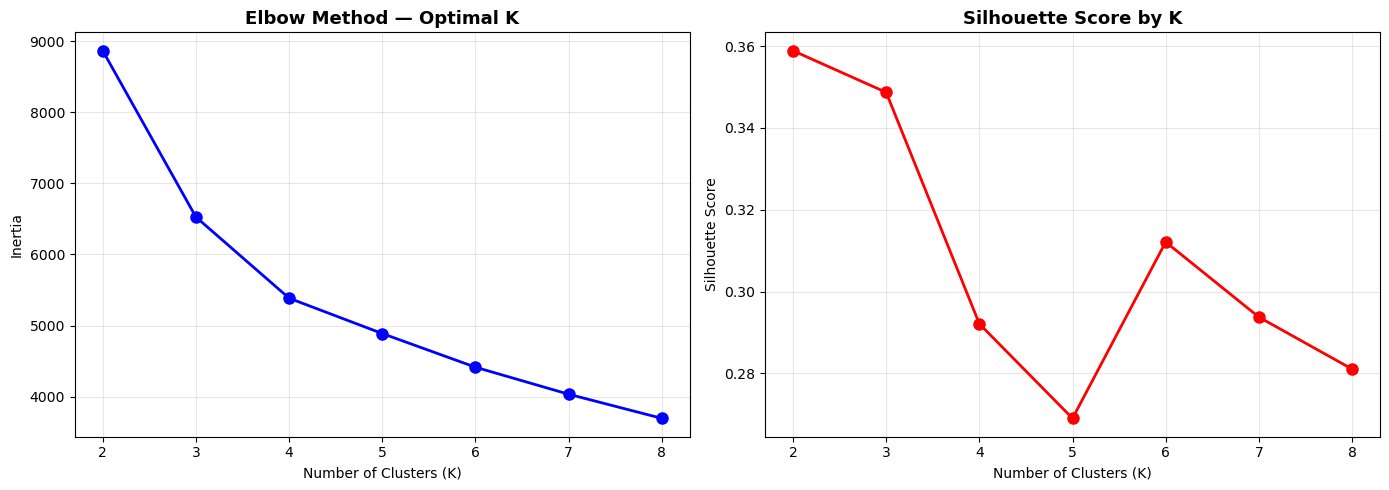

In [36]:
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

Run K-Means with K=5:

In [37]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(combined_features)

print("✅ K-Means done!")
print(f"Silhouette Score (K=5): {silhouette_score(combined_features, df['kmeans_cluster'], sample_size=500):.3f}")
print("\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

✅ K-Means done!
Silhouette Score (K=5): 0.266

Cluster distribution:
kmeans_cluster
0    677
1    792
2    665
3    500
4    366
Name: count, dtype: int64


PCA Visualization:


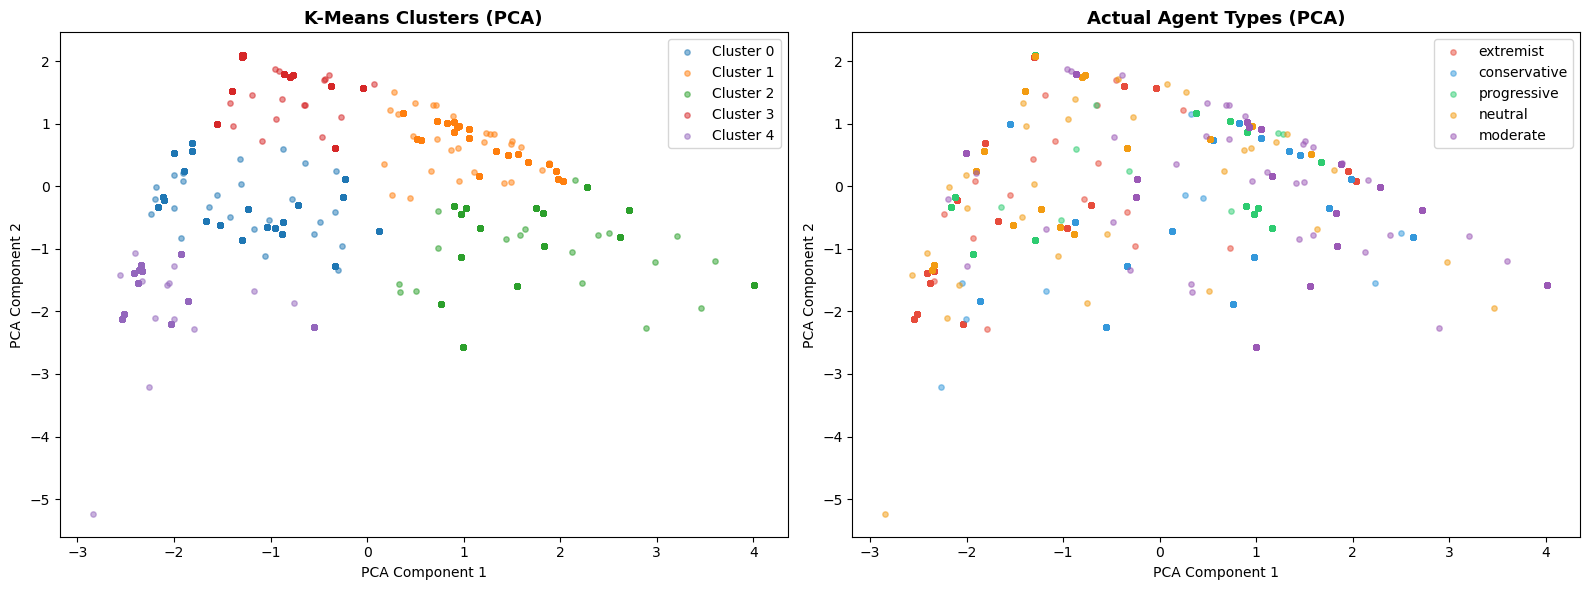

In [38]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(combined_features.toarray())
df['pca_x'] = pca_coords[:, 0]
df['pca_y'] = pca_coords[:, 1]

colors = {'extremist':'#e74c3c', 'conservative':'#3498db',
          'progressive':'#2ecc71', 'neutral':'#f39c12', 'moderate':'#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot by cluster
for cluster in range(5):
    mask = df['kmeans_cluster'] == cluster
    axes[0].scatter(df[mask]['pca_x'], df[mask]['pca_y'],
                   label=f'Cluster {cluster}', alpha=0.5, s=15)
axes[0].set_title('K-Means Clusters (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()

# Plot by agent type
for agent_type, color in colors.items():
    mask = df['agent_type'] == agent_type
    axes[1].scatter(df[mask]['pca_x'], df[mask]['pca_y'],
                   label=agent_type, color=color, alpha=0.5, s=15)
axes[1].set_title('Actual Agent Types (PCA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

 Cluster vs Agent Type comparison:

✅ Cluster vs Agent Type:
agent_type      conservative  extremist  moderate  neutral  progressive
kmeans_cluster                                                         
0                         70        140       149      173          145
1                        190         49       289       71          193
2                        106          1       379        4          175
3                         24        101        70      152          153
4                         71        181         1       63           50


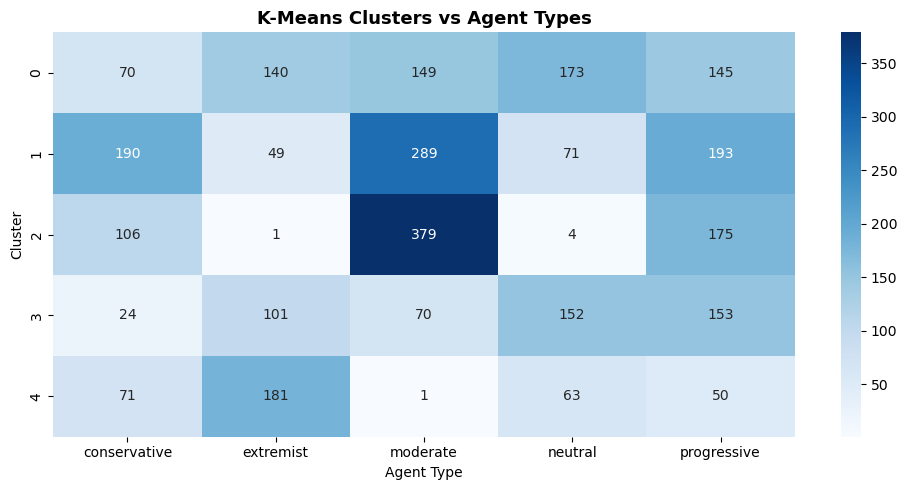

In [39]:

import seaborn as sns 
cluster_agent = pd.crosstab(df['kmeans_cluster'], df['agent_type'])
print("✅ Cluster vs Agent Type:")
print(cluster_agent)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_agent, annot=True, fmt='d', cmap='Blues')
plt.title('K-Means Clusters vs Agent Types', fontsize=13, fontweight='bold')
plt.xlabel('Agent Type')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('cluster_vs_agent.png', dpi=150, bbox_inches='tight')
plt.show()

Imports:

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print("✅ Classification libraries ready!")

✅ Classification libraries ready!


Prepare features:

In [41]:
import scipy.sparse as sp
import numpy as np

# Combine TF-IDF + sentiment + engagement features
extra_features = df[['sentiment_pos','sentiment_neg','sentiment_neu',
                      'sentiment_compound','likes','shares',
                      'engagement_score','word_count','hashtag_count',
                      'mention_count','bert_score']].fillna(0).values

scaler2 = StandardScaler()
extra_scaled = scaler2.fit_transform(extra_features)
extra_sparse = sp.csr_matrix(extra_scaled)
X = sp.hstack([tfidf_matrix, extra_sparse])

# Target — agent type classification
le = LabelEncoder()
y = le.fit_transform(df['agent_type'])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Features ready!")
print(f"   Training: {X_train.shape[0]} posts")
print(f"   Testing:  {X_test.shape[0]} posts")
print(f"   Classes:  {le.classes_}")

✅ Features ready!
   Training: 2400 posts
   Testing:  600 posts
   Classes:  ['conservative' 'extremist' 'moderate' 'neutral' 'progressive']


logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Random Forest:

In [46]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("✅ Random Forest Results:")
print(f"Accuracy: {rf.score(X_test, y_test):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

✅ Random Forest Results:
Accuracy: 0.990

Classification Report:
              precision    recall  f1-score   support

conservative       0.98      1.00      0.99        92
   extremist       0.99      0.99      0.99        94
    moderate       0.99      0.99      0.99       178
     neutral       0.99      0.97      0.98        93
 progressive       1.00      0.99      1.00       143

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



Confusion Matrix:

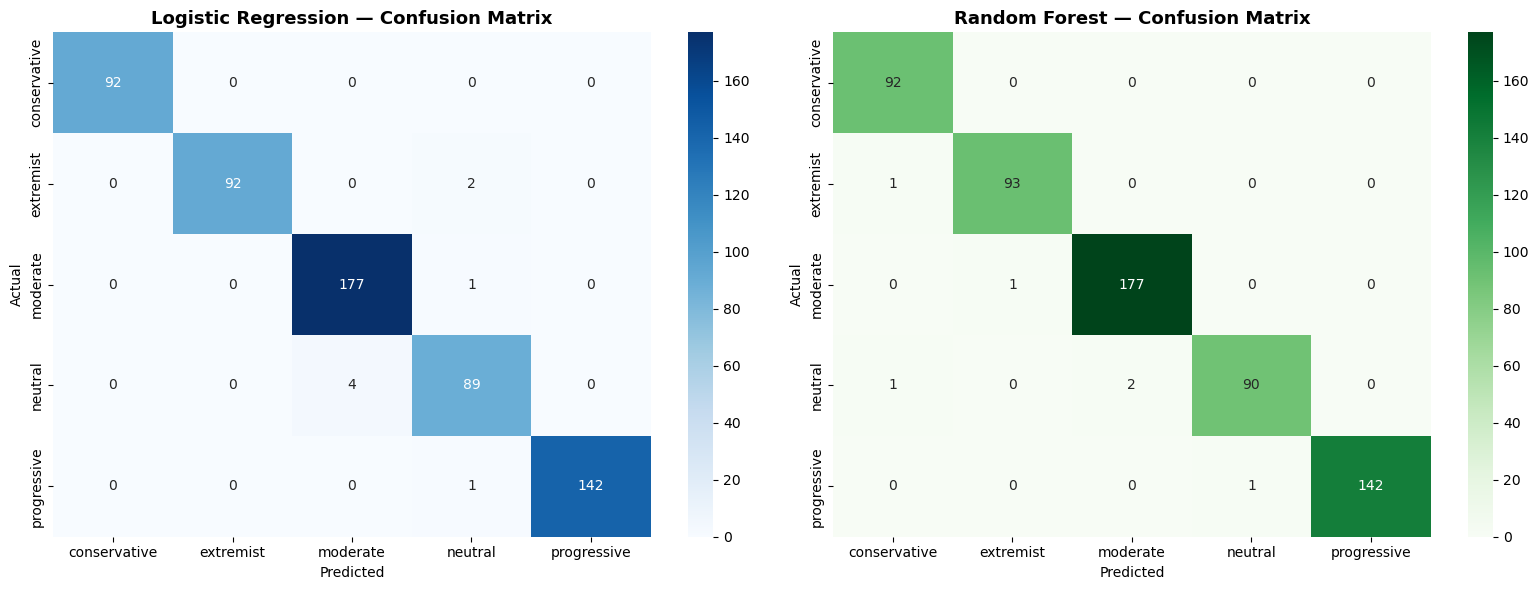

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Feature Importance:

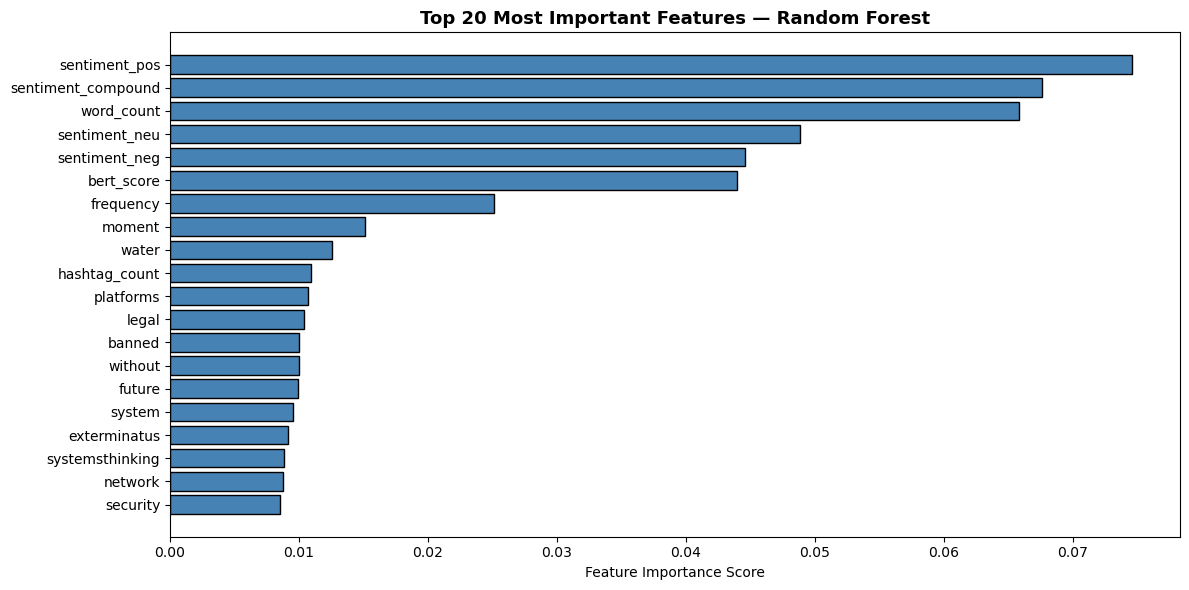

In [48]:
feature_names = tfidf.get_feature_names_out().tolist() + [
    'sentiment_pos','sentiment_neg','sentiment_neu','sentiment_compound',
    'likes','shares','engagement_score','word_count','hashtag_count',
    'mention_count','bert_score']

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
top_features = [feature_names[i] for i in top_idx]
top_scores = importances[top_idx]

plt.figure(figsize=(12, 6))
plt.barh(top_features[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
plt.title('Top 20 Most Important Features — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Classification

✅ Train: 2400 | Test: 600
Classes: ['conservative' 'extremist' 'moderate' 'neutral' 'progressive']

✅ Logistic Regression Accuracy: 0.987
✅ Random Forest Accuracy: 0.990

📊 Random Forest Classification Report:
              precision    recall  f1-score   support

conservative       0.98      1.00      0.99        92
   extremist       0.99      0.99      0.99        94
    moderate       0.99      0.99      0.99       178
     neutral       0.99      0.97      0.98        93
 progressive       1.00      0.99      1.00       143

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



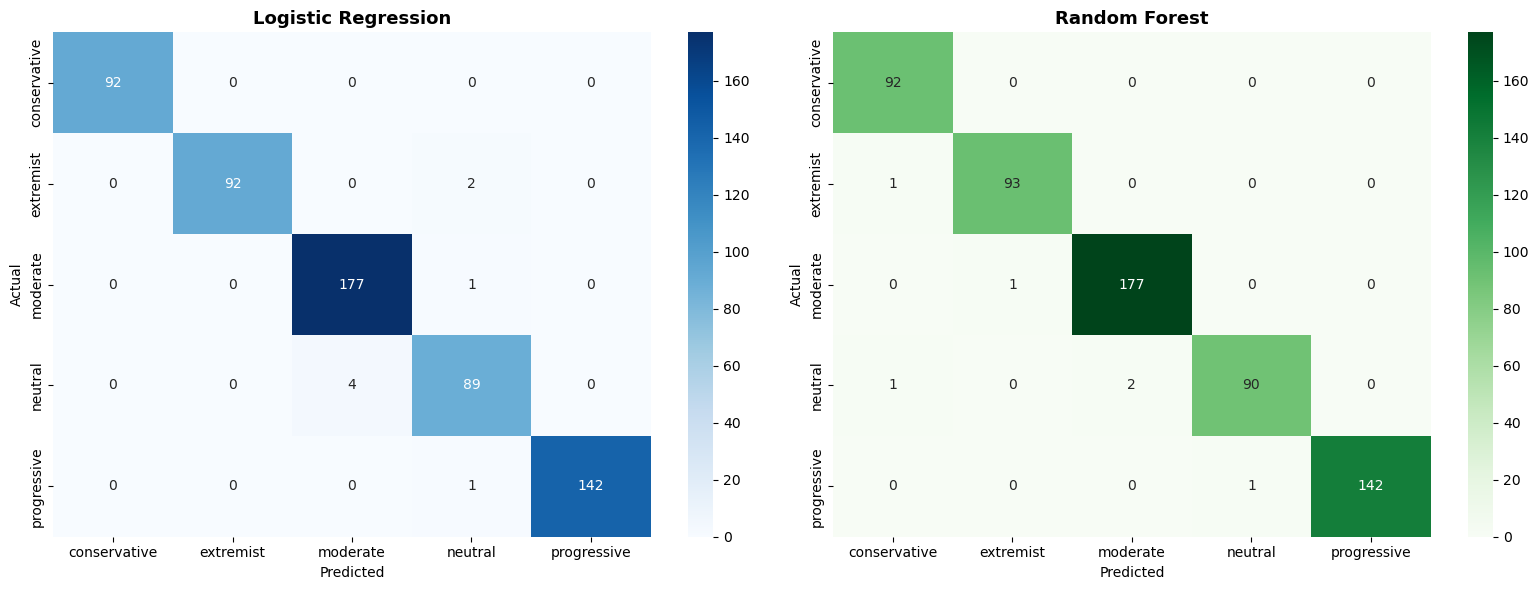

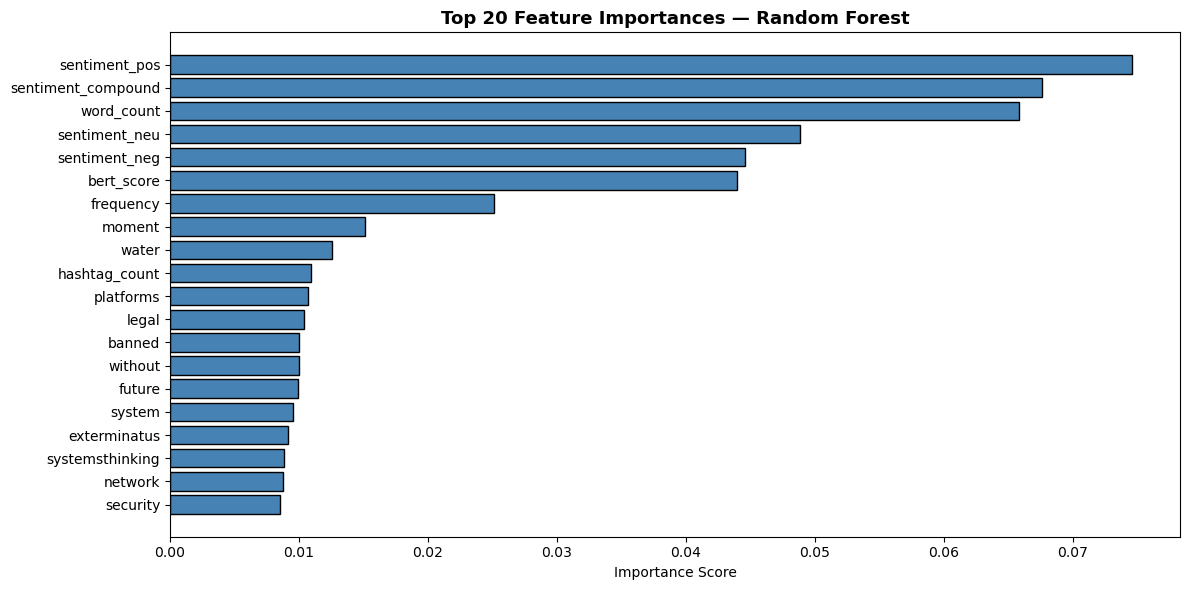


🎯 NUMBERS FOR YOUR PAPER:
Logistic Regression Accuracy: 98.7%
Random Forest Accuracy:       99.0%


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Features ──
extra_features = df[['sentiment_pos','sentiment_neg','sentiment_neu',
                      'sentiment_compound','likes','shares',
                      'engagement_score','word_count',
                      'hashtag_count','mention_count']].fillna(0).values

if 'bert_score' in df.columns:
    bert_scores = df[['bert_score']].fillna(0).values
    extra_features = np.hstack([extra_features, bert_scores])

scaler = StandardScaler()
extra_scaled = scaler.fit_transform(extra_features)
extra_sparse = sp.csr_matrix(extra_scaled)
X = sp.hstack([tfidf_matrix, extra_sparse])

le = LabelEncoder()
y = le.fit_transform(df['agent_type'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Classes: {le.classes_}")

# ── Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"\n✅ Logistic Regression Accuracy: {lr.score(X_test, y_test):.3f}")

# ── Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"✅ Random Forest Accuracy: {rf.score(X_test, y_test):.3f}")

print("\n📊 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Random Forest', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Feature Importance ──
feature_names = tfidf.get_feature_names_out().tolist()
extra_names = ['sentiment_pos','sentiment_neg','sentiment_neu',
               'sentiment_compound','likes','shares',
               'engagement_score','word_count','hashtag_count',
               'mention_count']
if 'bert_score' in df.columns:
    extra_names.append('bert_score')
all_features = feature_names + extra_names

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
top_features = [all_features[i] for i in top_idx]
top_scores = importances[top_idx]

plt.figure(figsize=(12, 6))
plt.barh(top_features[::-1], top_scores[::-1],
         color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances — Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎯 NUMBERS FOR YOUR PAPER:")
print(f"Logistic Regression Accuracy: {lr.score(X_test, y_test)*100:.1f}%")
print(f"Random Forest Accuracy:       {rf.score(X_test, y_test)*100:.1f}%")

Network Analysis

✅ Graph built!
   Nodes (agents): 748
   Edges (replies): 837

📊 Centrality by Agent Type:
              betweenness  pagerank  degree_c
agent_type                                   
conservative          0.0    0.0013    0.0383
extremist             0.0    0.0013    0.0177
moderate              0.0    0.0013    0.0401
neutral               0.0    0.0013    0.0239
progressive           0.0    0.0013    0.0444

✅ Connected components: 65


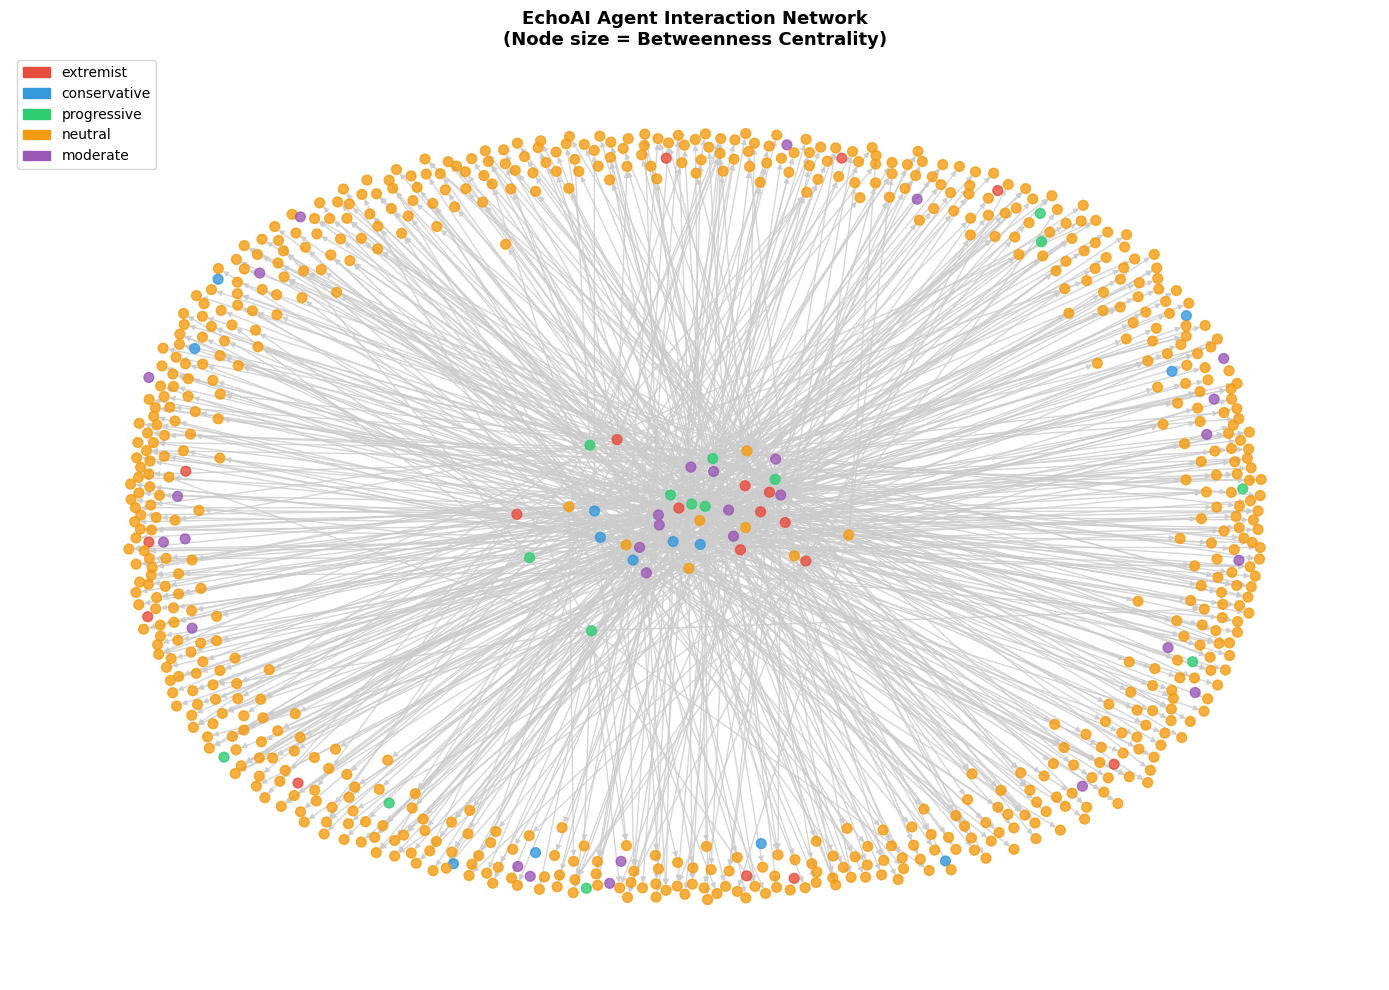


🎯 NUMBERS FOR YOUR PAPER:
Total agents in network: 748
Total reply edges:       837
Communities detected:    65

Highest betweenness centrality by agent type:
agent_type
conservative    0.0
extremist       0.0
moderate        0.0
neutral         0.0
progressive     0.0
Name: betweenness, dtype: float64


In [50]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Build Graph ──
G = nx.DiGraph()

for _, row in df.iterrows():
    agent = str(row['agent_name'])
    agent_type = str(row['agent_type'])
    G.add_node(agent, agent_type=agent_type)

    reply = row.get('reply_to', None)
    if reply and str(reply) not in ['nan', 'None', '']:
        G.add_edge(agent, str(reply))

print(f"✅ Graph built!")
print(f"   Nodes (agents): {G.number_of_nodes()}")
print(f"   Edges (replies): {G.number_of_edges()}")

# ── Centrality ──
betweenness = nx.betweenness_centrality(G)
pagerank    = nx.pagerank(G, max_iter=200)
degree      = nx.degree_centrality(G)

df['betweenness'] = df['agent_name'].map(betweenness).fillna(0)
df['pagerank']    = df['agent_name'].map(pagerank).fillna(0)
df['degree_c']    = df['agent_name'].map(degree).fillna(0)

# ── By Agent Type ──
centrality_by_type = df.groupby('agent_type')[
    ['betweenness','pagerank','degree_c']].mean().round(4)
print("\n📊 Centrality by Agent Type:")
print(centrality_by_type)

# ── Community Detection ──
G_undirected = G.to_undirected()
try:
    from community import community_louvain
    partition = community_louvain.best_partition(G_undirected)
    num_communities = len(set(partition.values()))
    print(f"\n✅ Communities detected: {num_communities}")
except:
    communities = list(nx.connected_components(G_undirected))
    num_communities = len(communities)
    print(f"\n✅ Connected components: {num_communities}")

# ── Visualize ──
colors = {
    'extremist':   '#e74c3c',
    'conservative':'#3498db',
    'progressive': '#2ecc71',
    'neutral':     '#f39c12',
    'moderate':    '#9b59b6'
}

node_colors = []
node_sizes  = []
for node in G.nodes():
    atype = G.nodes[node].get('agent_type', 'neutral')
    node_colors.append(colors.get(atype, '#95a5a6'))
    node_sizes.append(betweenness.get(node, 0) * 5000 + 50)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw_networkx(G, pos,
                 node_color=node_colors,
                 node_size=node_sizes,
                 with_labels=False,
                 edge_color='#cccccc',
                 alpha=0.8,
                 arrows=True,
                 arrowsize=8)

from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in colors.items()]
plt.legend(handles=legend, loc='upper left', fontsize=10)
plt.title('EchoAI Agent Interaction Network\n(Node size = Betweenness Centrality)',
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎯 NUMBERS FOR YOUR PAPER:")
print(f"Total agents in network: {G.number_of_nodes()}")
print(f"Total reply edges:       {G.number_of_edges()}")
print(f"Communities detected:    {num_communities}")
print("\nHighest betweenness centrality by agent type:")
print(centrality_by_type['betweenness'].sort_values(ascending=False))

Time Series + Mann-Kendall

✅ Daily polarization calculated!
    day  polarization_ratio
0     1            0.214286
1     2            0.229885
2     3            0.139785
3     4            0.168317
4     5            0.232323
5     6            0.110000
6     7            0.107843
7     8            0.201835
8     9            0.200000
9    10            0.108108
10   11            0.196262
11   12            0.213675
12   13            0.138211
13   14            0.234694
14   15            0.148936
15   16            0.097087
16   17            0.133929
17   18            0.147059
18   19            0.136364
19   20            0.123810
20   21            0.106195
21   22            0.135417
22   23            0.196078
23   24            0.086957
24   25            0.200000
25   26            0.145631
26   27            0.105263
27   28            0.118812
28   29            0.164835
29   30            0.175439

📊 Mann-Kendall Test Results:
   Tau (τ):  -0.239
   P-value:  0.0635
   ❌ No statistically signifi

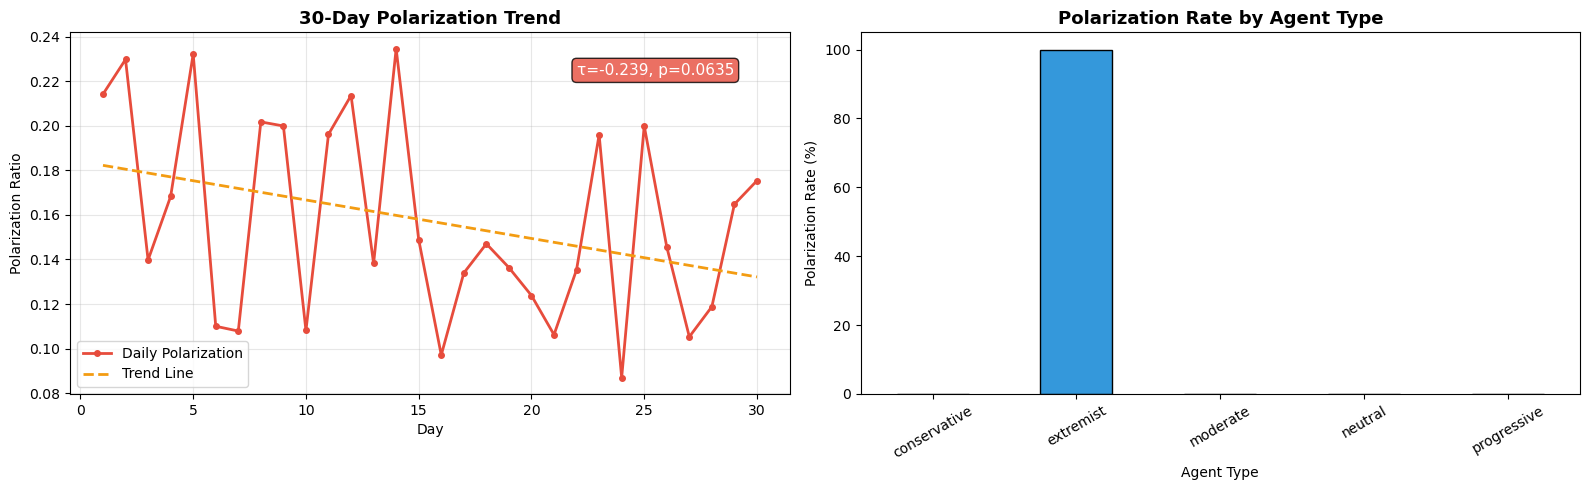


🎯 NUMBERS FOR YOUR PAPER:
Mann-Kendall τ = -0.239
P-value        = 0.0635
Significant    = No ❌


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau
import warnings
warnings.filterwarnings('ignore')

# ── Build 30-day series ──
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_sorted = df.sort_values('timestamp').copy()

min_date = df_sorted['timestamp'].min()
df_sorted['day'] = (df_sorted['timestamp'] - min_date).dt.days + 1
df_sorted['day'] = df_sorted['day'].clip(1, 30)

daily = df_sorted.groupby('day')['is_polarized'].mean().reset_index()
daily.columns = ['day', 'polarization_ratio']

all_days = pd.DataFrame({'day': range(1, 31)})
daily = all_days.merge(daily, on='day', how='left')
daily['polarization_ratio'] = daily['polarization_ratio'].fillna(
    daily['polarization_ratio'].mean())

print("✅ Daily polarization calculated!")
print(daily.to_string())

# ── Mann-Kendall ──
tau, p_value = kendalltau(daily['day'], daily['polarization_ratio'])

print(f"\n📊 Mann-Kendall Test Results:")
print(f"   Tau (τ):  {tau:.3f}")
print(f"   P-value:  {p_value:.4f}")

if p_value < 0.05:
    print(f"   ✅ Statistically significant trend!")
    if tau > 0:
        print(f"   📈 Direction: UPWARD (polarization is increasing)")
    else:
        print(f"   📉 Direction: DOWNWARD")
else:
    print(f"   ❌ No statistically significant trend (p > 0.05)")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Trend chart
z = np.polyfit(daily['day'], daily['polarization_ratio'], 1)
trend = np.poly1d(z)

axes[0].plot(daily['day'], daily['polarization_ratio'],
             color='#e74c3c', linewidth=2,
             marker='o', markersize=4, label='Daily Polarization')
axes[0].plot(daily['day'], trend(daily['day']),
             '--', color='#f39c12', linewidth=2, label='Trend Line')
axes[0].annotate(f'τ={tau:.3f}, p={p_value:.4f}',
                 xy=(22, daily['polarization_ratio'].max() * 0.95),
                 fontsize=11, color='white',
                 bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.8))
axes[0].set_title('30-Day Polarization Trend', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Polarization Ratio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Agent type polarization
polar_by_type = df.groupby('agent_type')['is_polarized'].mean() * 100
colors_list = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
polar_by_type.plot(kind='bar', ax=axes[1],
                   color=colors_list, edgecolor='black')
axes[1].set_title('Polarization Rate by Agent Type',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Agent Type')
axes[1].set_ylabel('Polarization Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('polarization_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎯 NUMBERS FOR YOUR PAPER:")
print(f"Mann-Kendall τ = {tau:.3f}")
print(f"P-value        = {p_value:.4f}")
print(f"Significant    = {'Yes ✅' if p_value < 0.05 else 'No ❌'}")